In [1]:
import sys
import os
import torch
sys.path.append(os.path.abspath('../'))

from src.models.single_network import SingleNetwork
from src.models.mc_dropout import MCDropout
from src.models.deep_ensemble import DeepEnsemble
from src.training.trainer import ModelTrainer
from src.processing.preprocess import get_dataloaders_for_sipakmed, getdataframe_for_sipakmed
from src.processing.loading import load_image_folder
from src.utils.visualisation import plot_performance_curves, plot_metrics_performance, ReliabilityPlotter
import pandas as pd
import matplotlib.pyplot as plt


`{im_Dyskeratotic: 0, im_Koilocytic: 1, im_Metaplasticimage_path: 2, im_Parabasal:3, im_Superficial-Intermediate: 4}`

In [2]:
train_loader, val_loader, cal_loader, test_loader = get_dataloaders_for_sipakmed(batch_size=32, num_workers=4, model_type="resnet")


df_all = getdataframe_for_sipakmed(train_loader, val_loader, cal_loader, test_loader)
df_all

,subset,image_path,label_id,label_name
0,train,/home/conite/Documents/STAGE/HybridUncertainty...,1,im_Koilocytic
1,train,/home/conite/Documents/STAGE/HybridUncertainty...,0,im_Dyskeratotic
2,train,/home/conite/Documents/STAGE/HybridUncertainty...,4,im_Superficial-Intermediate
3,train,/home/conite/Documents/STAGE/HybridUncertainty...,0,im_Dyskeratotic
4,train,/home/conite/Documents/STAGE/HybridUncertainty...,4,im_Superficial-Intermediate
...,...,...,...,...
4044,test,/home/conite/Documents/STAGE/HybridUncertainty...,2,im_Metaplastic
4045,test,/home/conite/Documents/STAGE/HybridUncertainty...,4,im_Superficial-Intermediate
4046,test,/home/conite/Documents/STAGE/HybridUncertainty...,2,im_Metaplastic
4047,test,/home/conite/Documents/STAGE/HybridUncertainty...,3,im_Parabasal


In [3]:
single_net = SingleNetwork(
    num_classes=5,
    learning_rate=5e-4,
    patience=5,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    train_loader=train_loader,
    val_loader=val_loader,
    cal_loader=cal_loader,
    test_loader=test_loader,
    
)

mcdropout = MCDropout(
    num_classes=5,
    learning_rate=5e-4,
    patience=5,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    train_loader=train_loader,
    val_loader=val_loader,
    cal_loader=cal_loader,
    test_loader=test_loader,
    
)

deepensemble = DeepEnsemble(
    num_classes=5,
    learning_rate=5e-4,
    patience=5,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    train_loader=train_loader,
    val_loader=val_loader,
    cal_loader=cal_loader,
    test_loader=test_loader,
    
)


/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


**1.0 Evaluation**

In [4]:
# single_net.train(epochs=50, model_path='single_net_resnet_sipakmed.pth')
single_net.load('../experiments/results/sipakmed/best_model_sipakmed_resnet_single.pth')
results_sn = single_net.evaluate()
print(f"Accuracy: {results_sn['accuracy']} | F1: {results_sn['f1_score']} | Precision: {results_sn['precision']} | Recall: {results_sn['recall']} | Brier: {results_sn['brier_score']} ")

/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/models/base_model.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(pa

Accuracy: 0.9786184210526315 | F1: 0.9787279300145292 | Precision: 0.9797179452343897 | Recall: 0.9786184210526315 | Brier: 0.03434033319354057 


In [5]:
mcdropout.load('../experiments/results/sipakmed/best_model_sipakmed_resnet_mc_dropout.pth')
results_mcd = mcdropout.evaluate()
print(f"Accuracy: {results_mcd['accuracy']} | F1: {results_mcd['f1_score']} | Precision: {results_mcd['precision']} | Recall: {results_mcd['recall']} | Brier: {results_mcd['brier_score']} ")

/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/models/base_model.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(pa

Accuracy: 0.9819078947368421 | F1: 0.9819621919825497 | Precision: 0.9822748921228969 | Recall: 0.9819078947368421 | Brier: 0.027288945391774178 


In [6]:
deepensemble.load([
    f"/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/best_model_de_member_sipakmed_resnet_de_{i}.pth" for i in range(5)
])
results_de = deepensemble.evaluate()
print(f"Accuracy: {results_de['accuracy']} | F1: {results_de['f1_score']} | Precision: {results_de['precision']} | Recall: {results_de['recall']} | Brier: {results_de['brier_score']} ")


/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/models/deep_ensemble.py:125: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(model_path, map_location=

Model 1 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/best_model_de_member_sipakmed_resnet_de_0.pth
Model 2 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/best_model_de_member_sipakmed_resnet_de_1.pth
Model 3 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/best_model_de_member_sipakmed_resnet_de_2.pth
Model 4 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/best_model_de_member_sipakmed_resnet_de_3.pth
Model 5 loaded from /home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/best_model_de_member_sipakmed_resnet_de_4.pth

🔎 Predicting with ensemble member 1/5



🔎 Predicting with ensemble member 2/5



🔎 Predicting with ensemble member 3/5



🔎 Predicting with ensemble member 4/5



🔎 Predicting with ensemble member 5/5


Accuracy: 0.9917763157894737 | F1: 0.9917758079979202 | Precision: 0.9918154333688239 | Recall: 0.9917763157894737 | Brier: 0.01742463931441307 


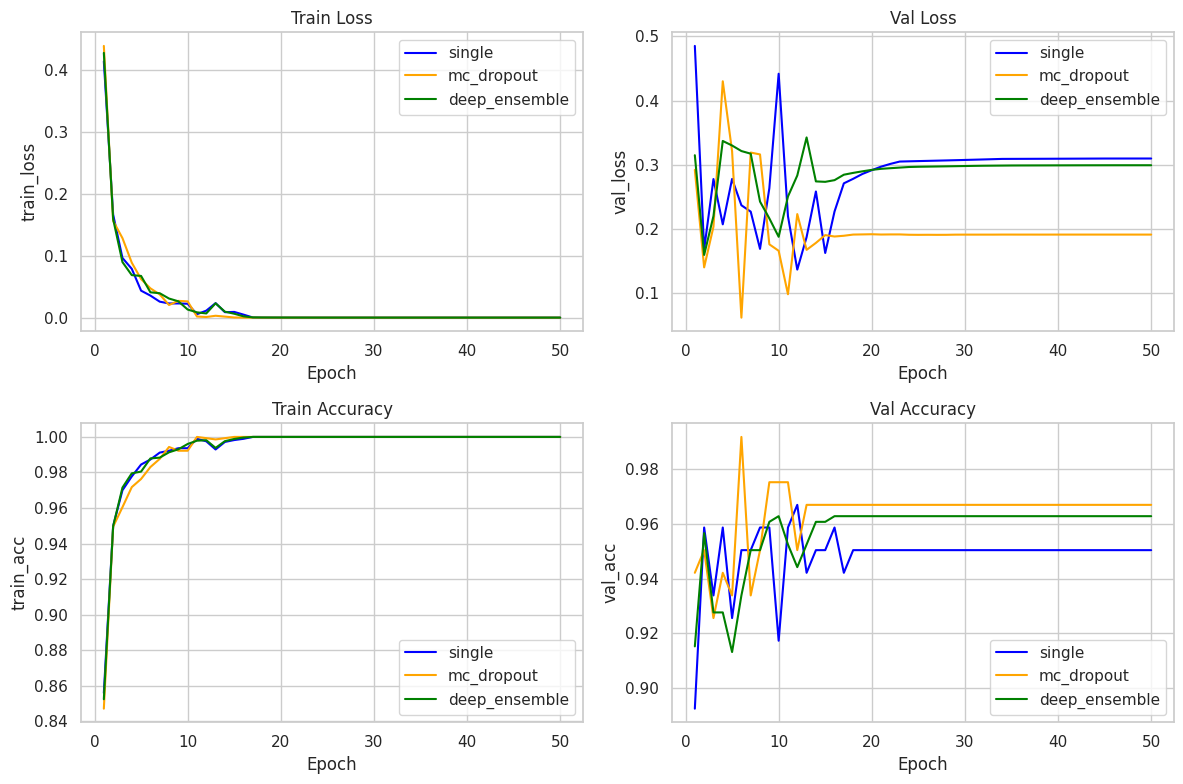

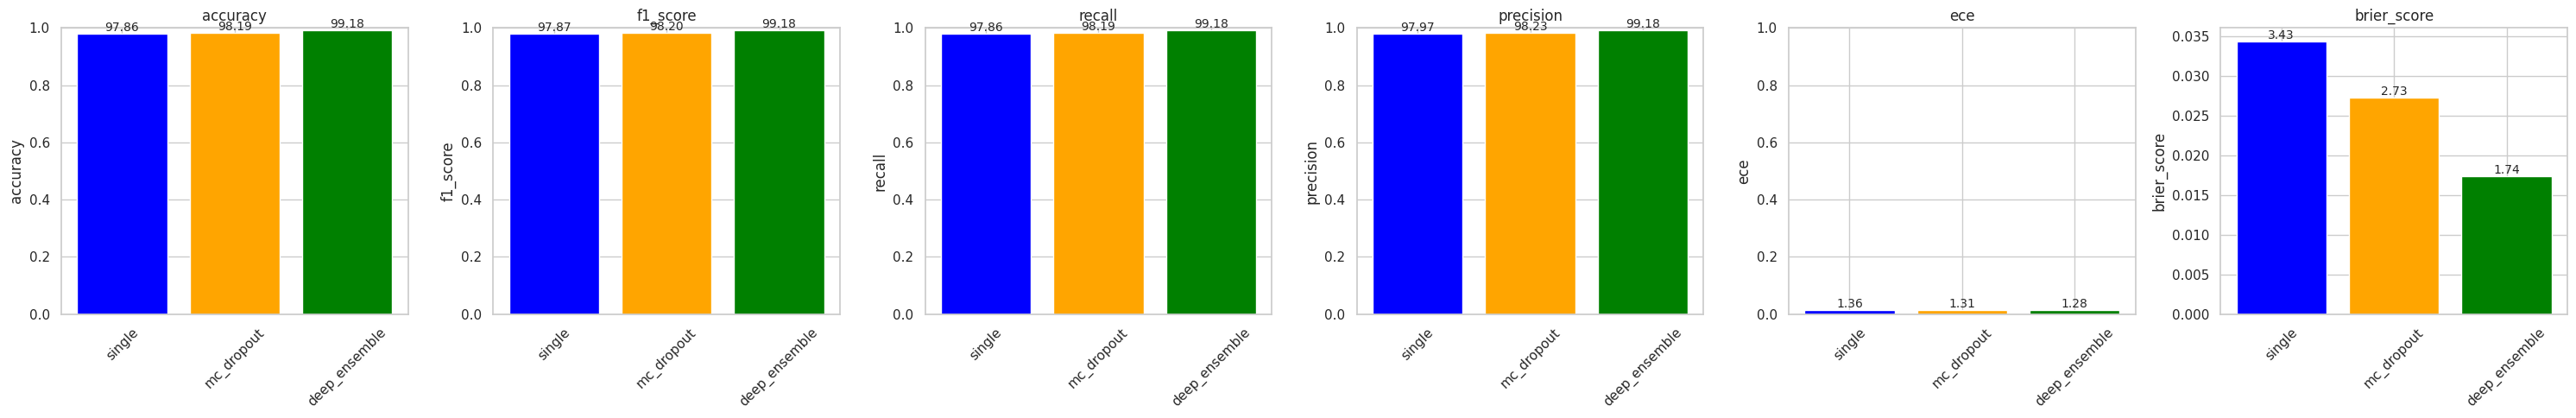

In [7]:
ENSEMBLE_SIZE = 5
path_results = {
    'single': os.path.join("/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_single_resnet50_sipakmed.json"),
    
    'mc_dropout': os.path.join("/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_mcdropout_resnet50_sipakmed.json"),
    'deep_ensemble': [
        os.path.join(f"/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/experiments/results/sipakmed/output_deepensemble_resnet50_sipakmed_{i}.json") 
        for i in range(1,ENSEMBLE_SIZE)
    ]
}

gather_results = {
    'single': results_sn,
    'mc_dropout': results_mcd,
    'deep_ensemble': results_de
}


plot_performance_curves(path_results=path_results)
plot_metrics_performance(gather_results)

**Step 2: Analyze each model's calibration performance (e.g., via ECE, Brier score), identifying which base approach is best calibrated across the three datasets**


Plotting reliability diagram for approach: single


<Figure size 600x500 with 0 Axes>

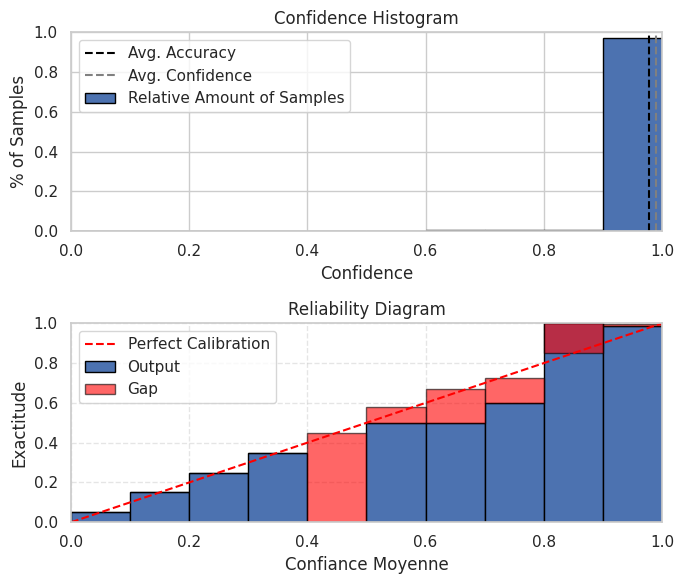

Plotting reliability diagram for approach: mc_dropout


<Figure size 600x500 with 0 Axes>

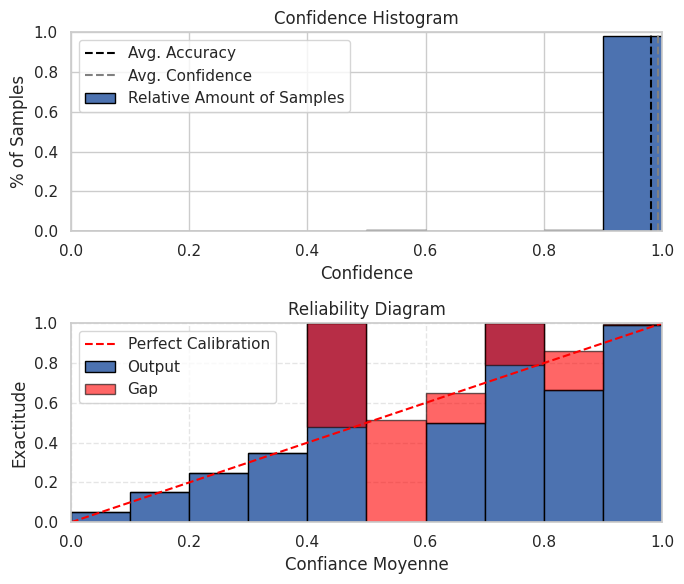

Plotting reliability diagram for approach: deep_ensemble


<Figure size 600x500 with 0 Axes>

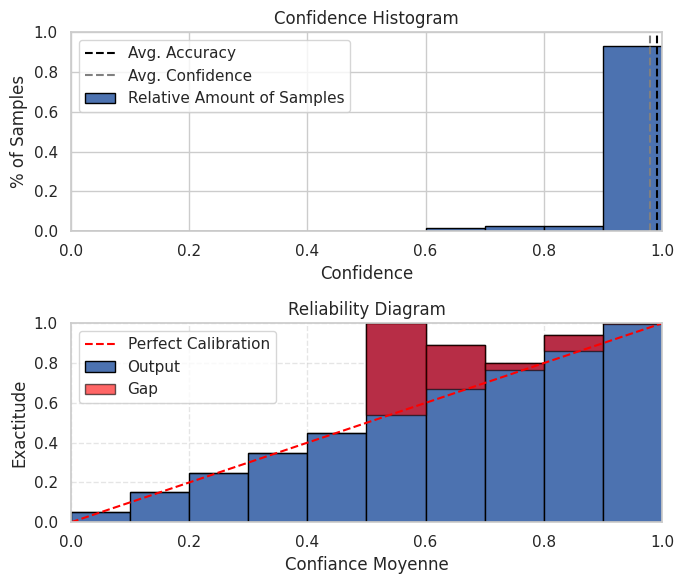

In [8]:
approaches_data = {
    'single': (results_sn['y_labels'], results_sn['y_probs']),
    'mc_dropout': (results_mcd['y_labels'], results_mcd['y_probs']),
    'deep_ensemble': (results_de['y_trues'], results_de['y_probs'])
}

plotter = ReliabilityPlotter(approaches_data)
plotter.plot_all_approaches(n_bins=10)

**Display Entropies, Gaps, Variances**

In [9]:
results_sn.keys()

dict_keys(['accuracy', 'f1_score', 'precision', 'recall', 'roc_auc', 'brier_score', 'entropy', 'uncertainty', 'ece', 'variance', 'y_preds', 'y_probs', 'y_labels'])

In [10]:
y_probs =  results_mcd['y_probs']
print(y_probs.shape)

(608, 5)


**Step 3: For each base method's (SingleNet, MCD, DE), apply APS, RAPS, and SAPS to create conformal sets, then compare their mean/median set sizes, marginal coverage, etc... and accuracy-per-set-size trade-offs to come out with the most efficient combinaison strategy on the three datasets.**

In [11]:
# get number of correctly predicted and misclassified samples with probas=results_sn['y_probs'], labels=results_sn['y_labels']
import numpy as np

def get_correctly_predicted_and_misclassified_samples(probas, labels):
    correctly_predicted = []
    misclassified = []
    predicted_classes = np.argmax(probas, axis=1)  # Get predicted classes from probabilities
    for i in range(len(predicted_classes)):
        if predicted_classes[i] == labels[i]:
            correctly_predicted.append(i)
        else:
            misclassified.append(i)
    return correctly_predicted, misclassified

correctly_predicted_sn, misclassified_sn = get_correctly_predicted_and_misclassified_samples(results_sn['y_probs'], results_sn['y_labels'])
print(f"Single Net | Number of correctly predicted samples: {len(correctly_predicted_sn)}")
print(f"Single Net | Number of misclassified samples: {len(misclassified_sn)}")

correctly_predicted_mcd, misclassified_mcd = get_correctly_predicted_and_misclassified_samples(results_mcd['y_probs'], results_mcd['y_labels'])
print(f"MC Dropout | Number of correctly predicted samples: {len(correctly_predicted_mcd)}")
print(f"MC Dropout | Number of misclassified samples: {len(misclassified_mcd)}")

correctly_predicted_de, misclassified_de = get_correctly_predicted_and_misclassified_samples(results_de['y_probs'], results_de['y_trues'])
print(f"Deep Ensemble | Number of correctly predicted samples: {len(correctly_predicted_de)}")
print(f"Deep Ensemble | Number of misclassified samples: {len(misclassified_de)}")

Single Net | Number of correctly predicted samples: 595
Single Net | Number of misclassified samples: 13
MC Dropout | Number of correctly predicted samples: 597
MC Dropout | Number of misclassified samples: 11
Deep Ensemble | Number of correctly predicted samples: 603
Deep Ensemble | Number of misclassified samples: 5


**3.1 Find best hyperparameters**

In [12]:
# ====== BLOC 1: Imports et Paramètres ======
import numpy as np
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from src.conformal_prediction.cp_old import ConformalPredictor

# Paramètres d'exploration
lambda_values = np.linspace(0, 1, 6)
k_reg_values = range(5)
randomize_values = [True, False]
alpha = 0.05

cp_methods = ['aps', 'raps', 'saps', 'gaps', 'eaps', 'geaps']

approaches = {
    'single': results_sn,
    'mcdropout': results_mcd,
    'deepensemble': results_de
}


# ====== BLOC 2: Fonctions d'évaluation ======
def compute_singleton_backup(y_true, y_preds, pred_sets):
    total_errors = sum(y != y_pred for y, y_pred in zip(y_true, y_preds))
    singleton_errors = [
        i for i, s in enumerate(pred_sets)
        if len(s) == 1 and y_true[i] not in s
    ]
    backup_rate = 1 - (len(singleton_errors) / total_errors) if total_errors > 0 else 0
    return backup_rate, len(singleton_errors), total_errors


def evaluate_cp_backup(results_dict, alpha, method, approach_name):
    backup_results = {}
    for l in lambda_values:
        for k in k_reg_values:
            for rand in randomize_values:
                predictor = ConformalPredictor(
                    method=method,
                    lambda_param=l,
                    k_reg=k,
                    randomize=rand
                )
                predictor.calibrate(
                    cal_probs=results_dict['y_probs'],
                    cal_labels=results_dict['y_labels'] if 'y_labels' in results_dict else results_dict['y_trues'],
                    cal_yvars=results_dict['variance'],
                    alpha=alpha
                )
                pred_sets = [predictor.predict(x)[0] for x in results_dict['y_probs']]

                y_true = results_dict['y_labels'] if 'y_labels' in results_dict else results_dict['y_trues']
                y_preds = np.argmax(results_dict['y_probs'], axis=1)

                backup_rate, n_singleton, n_errors = compute_singleton_backup(y_true, y_preds, pred_sets)
                backup_results[(l, k, rand)] = {
                    'backup_rate': backup_rate,
                    'singleton_errors': n_singleton,
                    'total_errors': n_errors
                }

    return backup_results

# ====== BLOC 3: Heatmaps alignées ======
def plot_method_row_heatmaps(backup_stats_dict, approach, randomize_flag):
    methods = list(backup_stats_dict.keys())
    n_methods = len(methods)

    fig, axs = plt.subplots(1, n_methods, figsize=(4 * n_methods, 5), squeeze=False)

    for j, method in enumerate(methods):
        stats = backup_stats_dict[method]

        data = {
            (round(l, 2), k): val['backup_rate']
            for (l, k, r), val in stats.items()
            if r == randomize_flag
        }
        df = pd.DataFrame.from_dict(data, orient='index')
        df.index = pd.MultiIndex.from_tuples(df.index, names=["lambda", "k_reg"])
        df = df.unstack().sort_index()

        sns.heatmap(
            df,
            annot=True,
            fmt=".2f",
            cmap="YlGnBu",
            cbar=False,
            ax=axs[0, j]
        )
        axs[0, j].set_title(f"{method.upper()} (rand={randomize_flag})")
        axs[0, j].set_ylabel("λ")
        axs[0, j].set_xlabel("k_reg")

    plt.suptitle(f"{approach.upper()} – Backup Rate Heatmaps", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


🔍 Processing: SINGLE
  ➤ APS
  ➤ RAPS
[DEBUG] tau: 0.9543474379000113 | index: 578 | n: 608 | alpha: 0.05 | sorted_scores: [0.00152765 0.00622547 0.00630158 0.00639175 0.00683217 0.00722691
 0.00914761 0.00946013 0.01184752 0.01223985 0.01660283 0.01705805
 0.01863423 0.01982105 0.02175118 0.02278275 0.02755935 0.03429694
 0.03441576 0.03803603 0.03833563 0.04169333 0.04397682 0.04605444
 0.04671825 0.05268701 0.05345048 0.05556208 0.05570964 0.05574266
 0.05863392 0.06027085 0.06185126 0.07007667 0.07064951 0.07171839
 0.07507428 0.0750894  0.07602037 0.07603075 0.0760806  0.07745131
 0.08300297 0.08493399 0.08678992 0.08762664 0.09269193 0.09280364
 0.09473099 0.09480593 0.09950839 0.09981897 0.10188731 0.10464466
 0.10499387 0.11049213 0.11196836 0.11203986 0.11293251 0.11332512
 0.11567114 0.11789404 0.11808633 0.118406   0.11906866 0.12298888
 0.12625197 0.12811731 0.13030793 0.13052514 0.13123662 0.13249117
 0.1327932  0.13377632 0.1369883  0.13774549 0.13952457 0.1399046
 0.1433

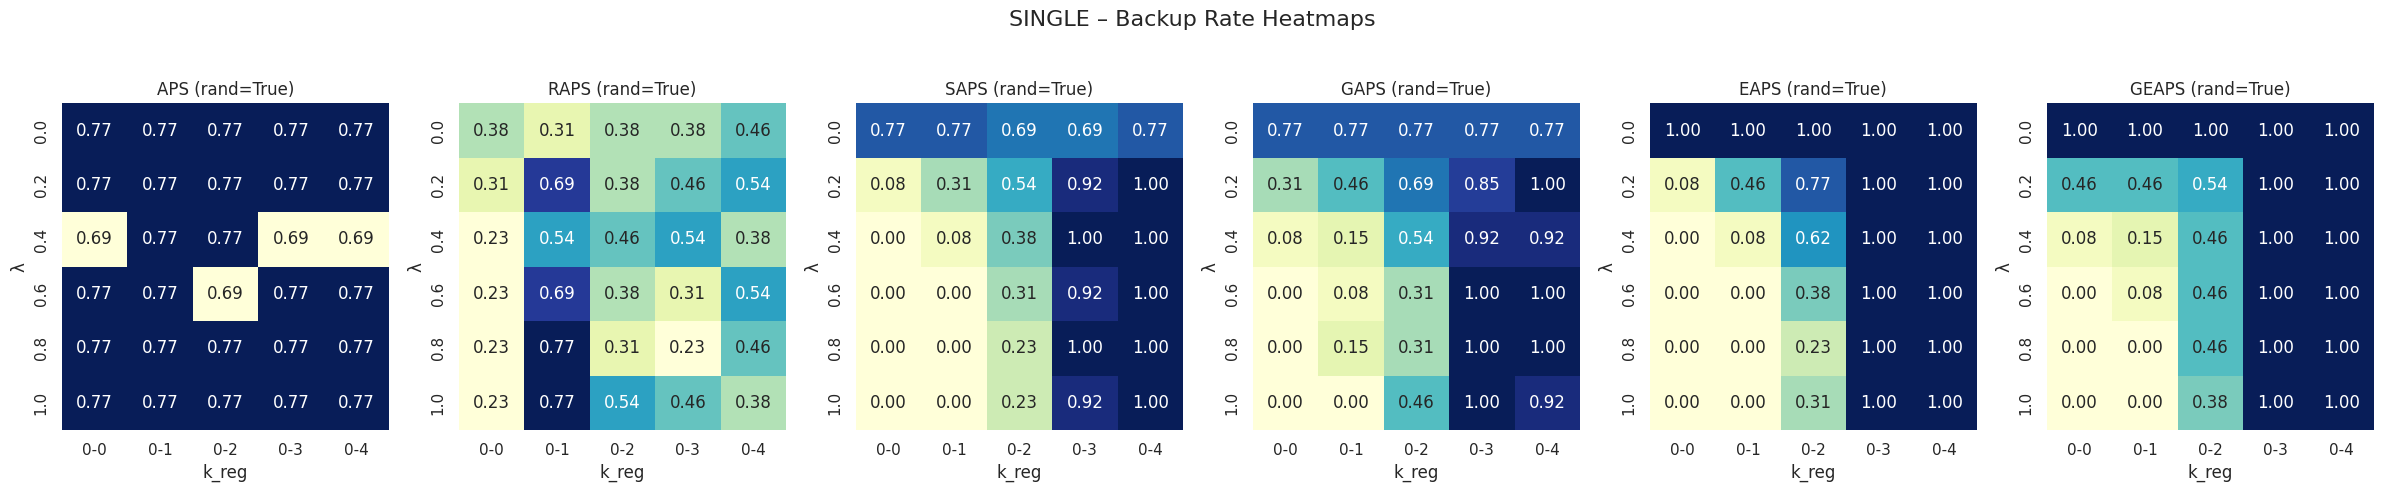

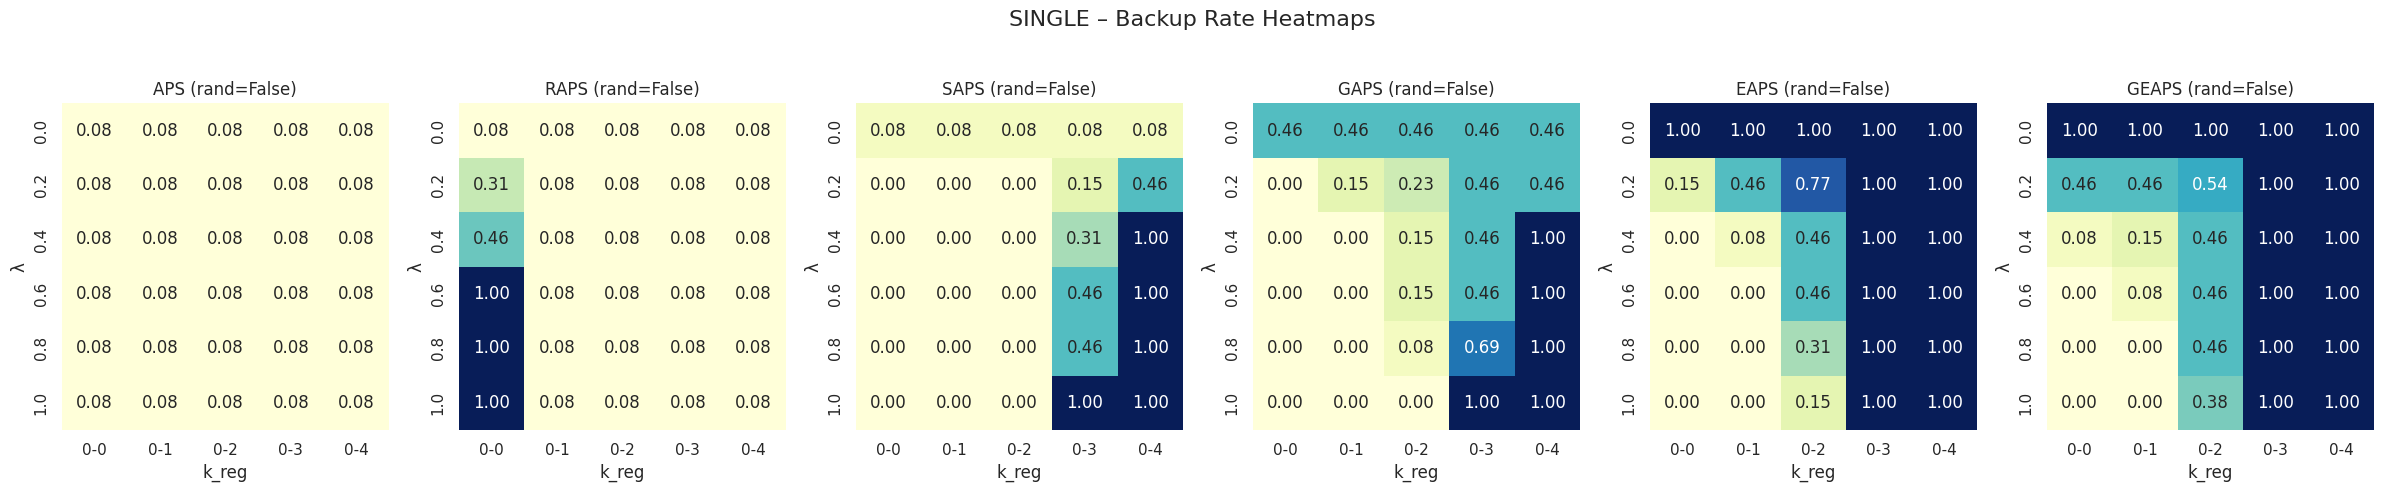

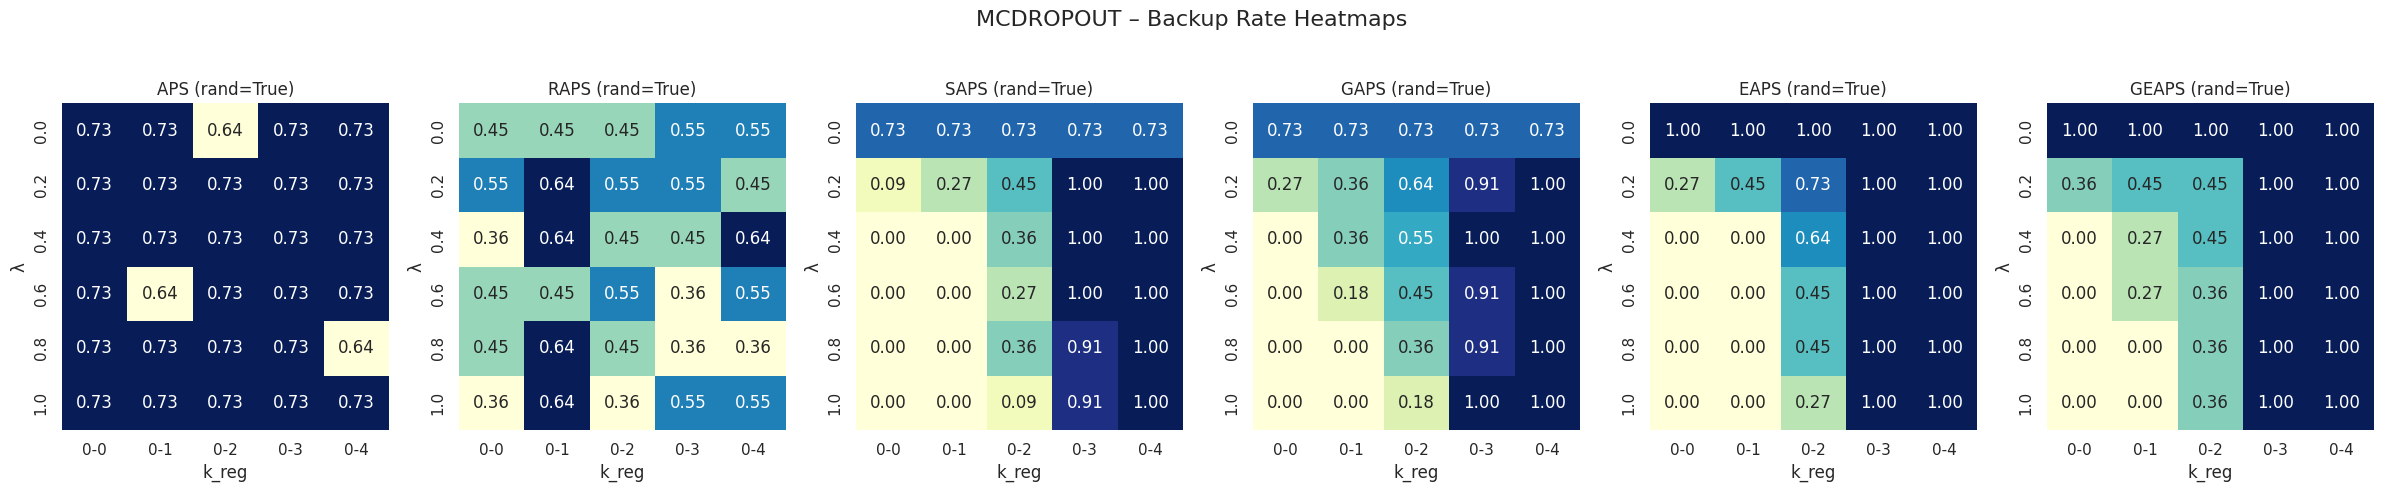

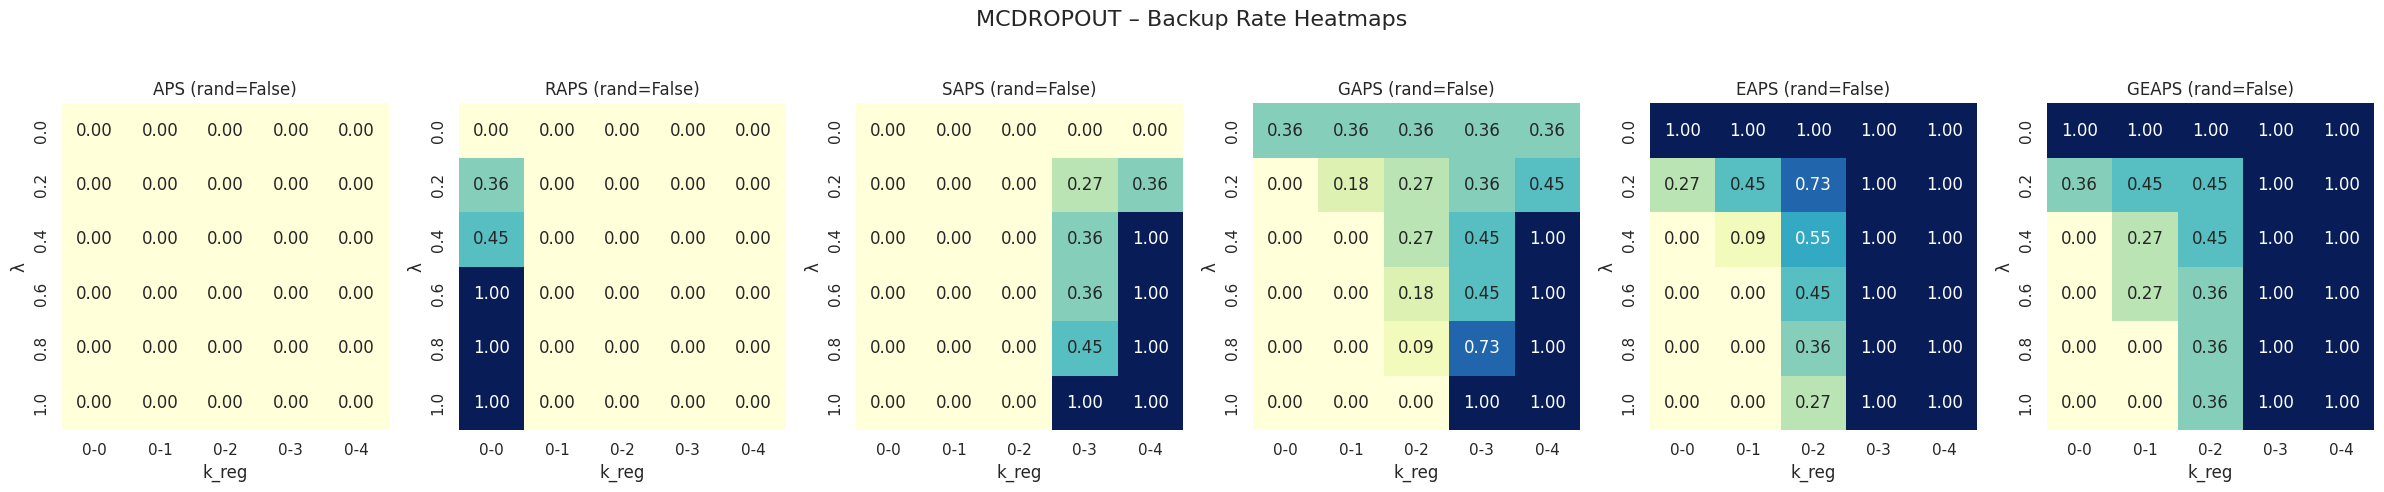

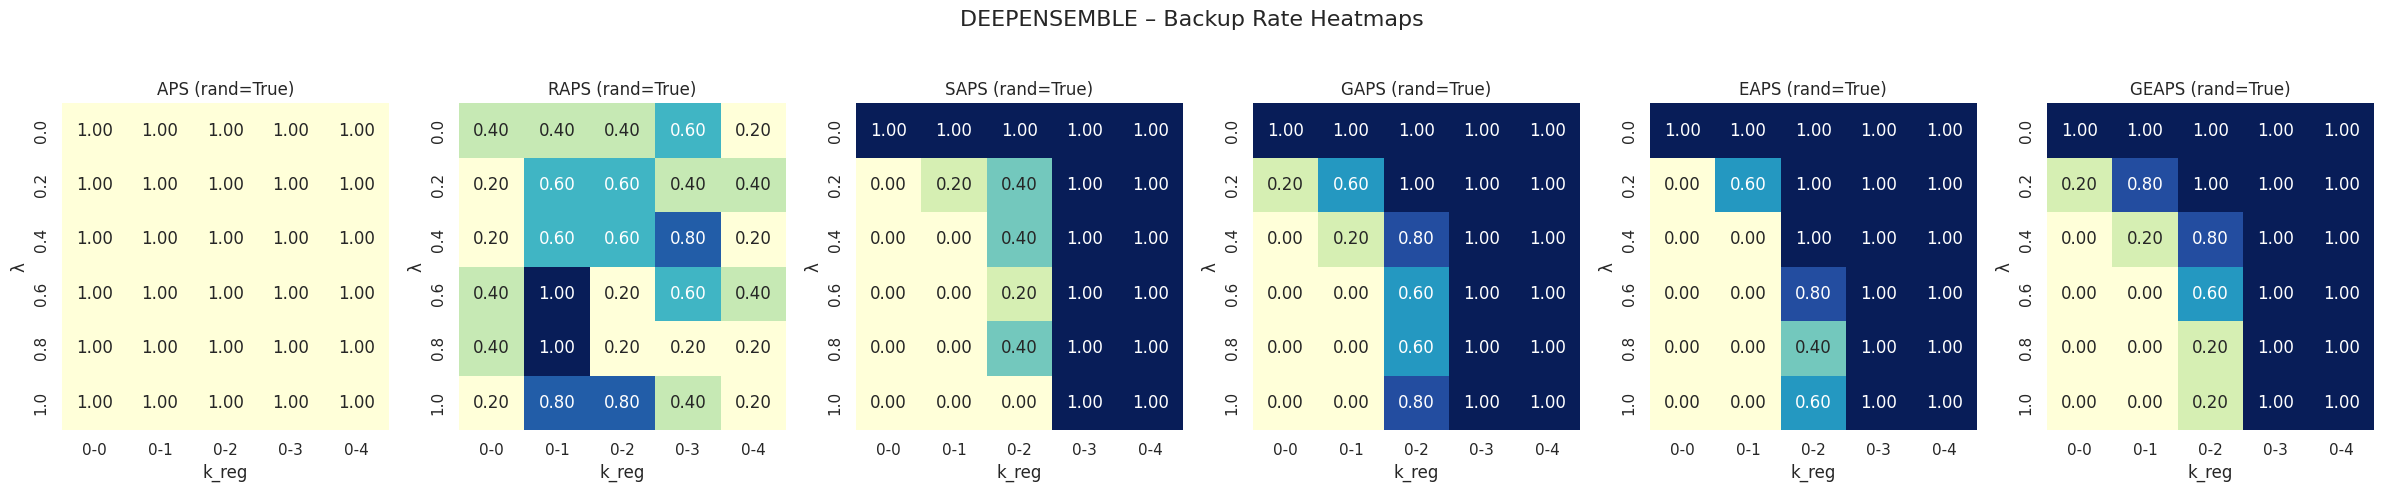

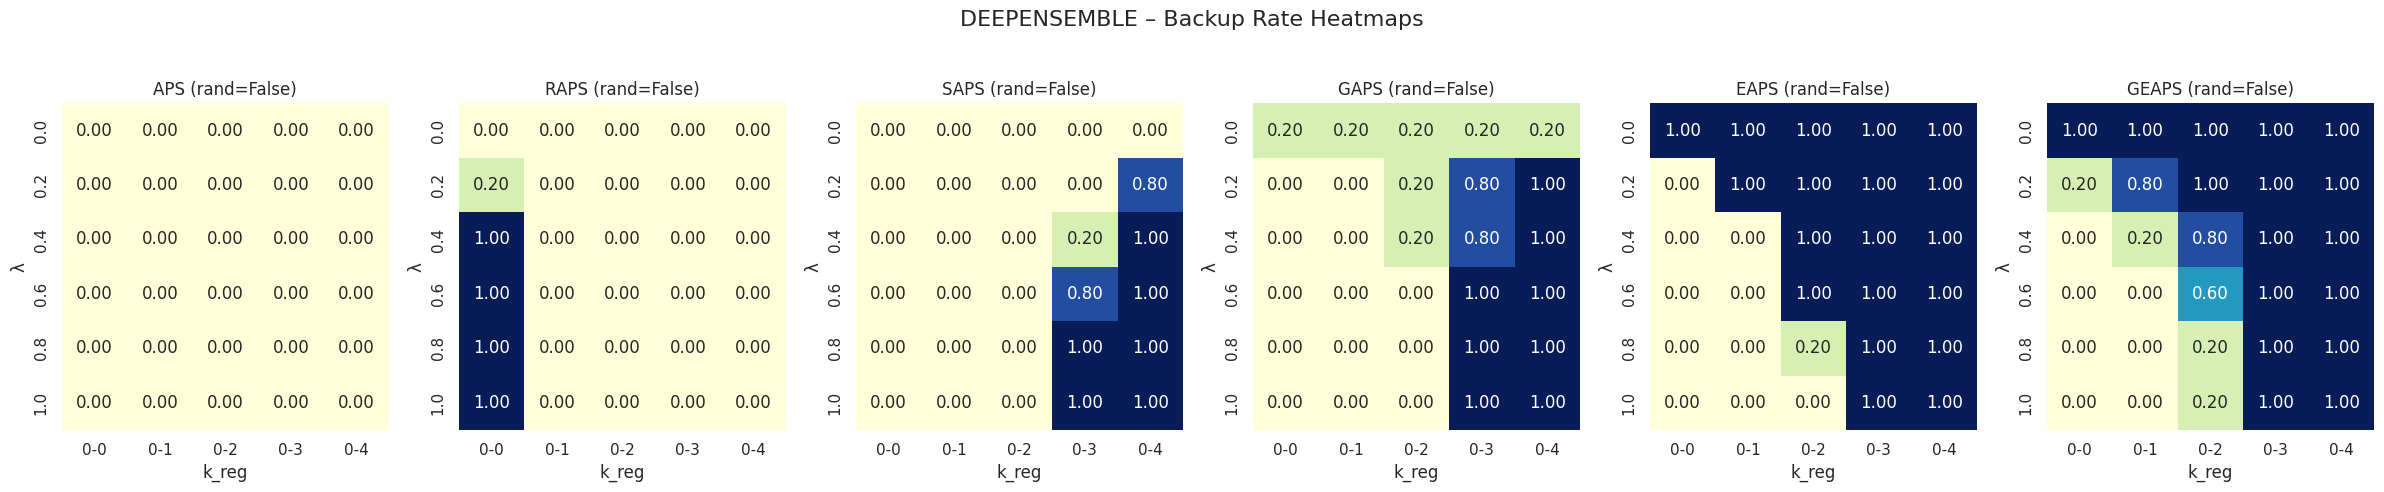

In [13]:
# ====== BLOC 4: Boucle d'évaluation et affichage ======
all_backup_stats = {}

# Étape 1 : calculer les stats
for approach_name, results in approaches.items():
    print(f"🔍 Processing: {approach_name.upper()}")
    all_backup_stats[approach_name] = {}

    for method in cp_methods:
        print(f"  ➤ {method.upper()}")
        backup_stats = evaluate_cp_backup(results, alpha, method, approach_name)
        all_backup_stats[approach_name][method] = backup_stats

# Étape 2 : afficher les heatmaps alignées
for approach_name in all_backup_stats:
    for rand_flag in randomize_values:
        plot_method_row_heatmaps(
            all_backup_stats[approach_name],
            approach_name,
            randomize_flag=rand_flag
        )


In [14]:
from src.conformal_prediction.cp_old import ConformalPredictor

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim


alpha = 0.05
predictors = {
    'APS': ConformalPredictor(method='aps', lambda_param=0, k_reg=0, randomize=True),
    'RAPS': ConformalPredictor(method='raps', lambda_param=0.75, k_reg=1, randomize=True),
    'SAPS': ConformalPredictor(method='saps', lambda_param=0.75, k_reg=2, randomize=True),
    'GAPS': ConformalPredictor(method='gaps', lambda_param=0.75, k_reg=2, randomize=True),
    'EAPS': ConformalPredictor(method='eaps', lambda_param=0.75, k_reg=2, randomize=True),
    'GEAPS': ConformalPredictor(method='geaps', lambda_param=0.75, k_reg=2, randomize=True),
}

for predictor_name, predictor in predictors.items():
    print(f"Calibrating {predictor_name}")
    cal_probs = results_sn['y_probs']
    cal_labels = results_sn['y_labels']
    cal_vars = results_sn['variance']    
    predictor.calibrate(cal_probs, cal_labels, cal_vars, alpha=alpha)
    print(f"Best tau: {predictor.tau}")


Calibrating APS
Best tau: 0.9610755271592368
Calibrating RAPS
[DEBUG] tau: 0.9627896765179939 | index: 578 | n: 608 | alpha: 0.05 | sorted_scores: [9.53161429e-04 3.41344076e-03 4.13519253e-03 4.43020736e-03
 6.31645534e-03 7.34803760e-03 9.20646695e-03 1.22286873e-02
 1.27228916e-02 1.52400654e-02 1.65720521e-02 1.91548692e-02
 2.17585274e-02 2.44970546e-02 2.68458626e-02 2.71921321e-02
 2.75317336e-02 3.00679331e-02 3.00860029e-02 3.26943507e-02
 3.29442024e-02 3.50757714e-02 3.53578895e-02 3.82659925e-02
 3.96849194e-02 4.26629159e-02 4.38750013e-02 4.39186356e-02
 4.52191722e-02 4.53028833e-02 5.07694734e-02 5.11509264e-02
 5.25361503e-02 5.63661149e-02 6.37480901e-02 6.47857717e-02
 6.56320345e-02 6.75973084e-02 7.26992684e-02 7.27038943e-02
 7.31714603e-02 7.36604149e-02 7.44427620e-02 7.46169012e-02
 7.57942878e-02 7.64537646e-02 7.65914792e-02 7.82930969e-02
 7.85527576e-02 7.95618167e-02 8.10571302e-02 8.11546247e-02
 8.11742307e-02 8.45513695e-02 8.47984131e-02 8.84195821e-02

 <======================Single approach======================>


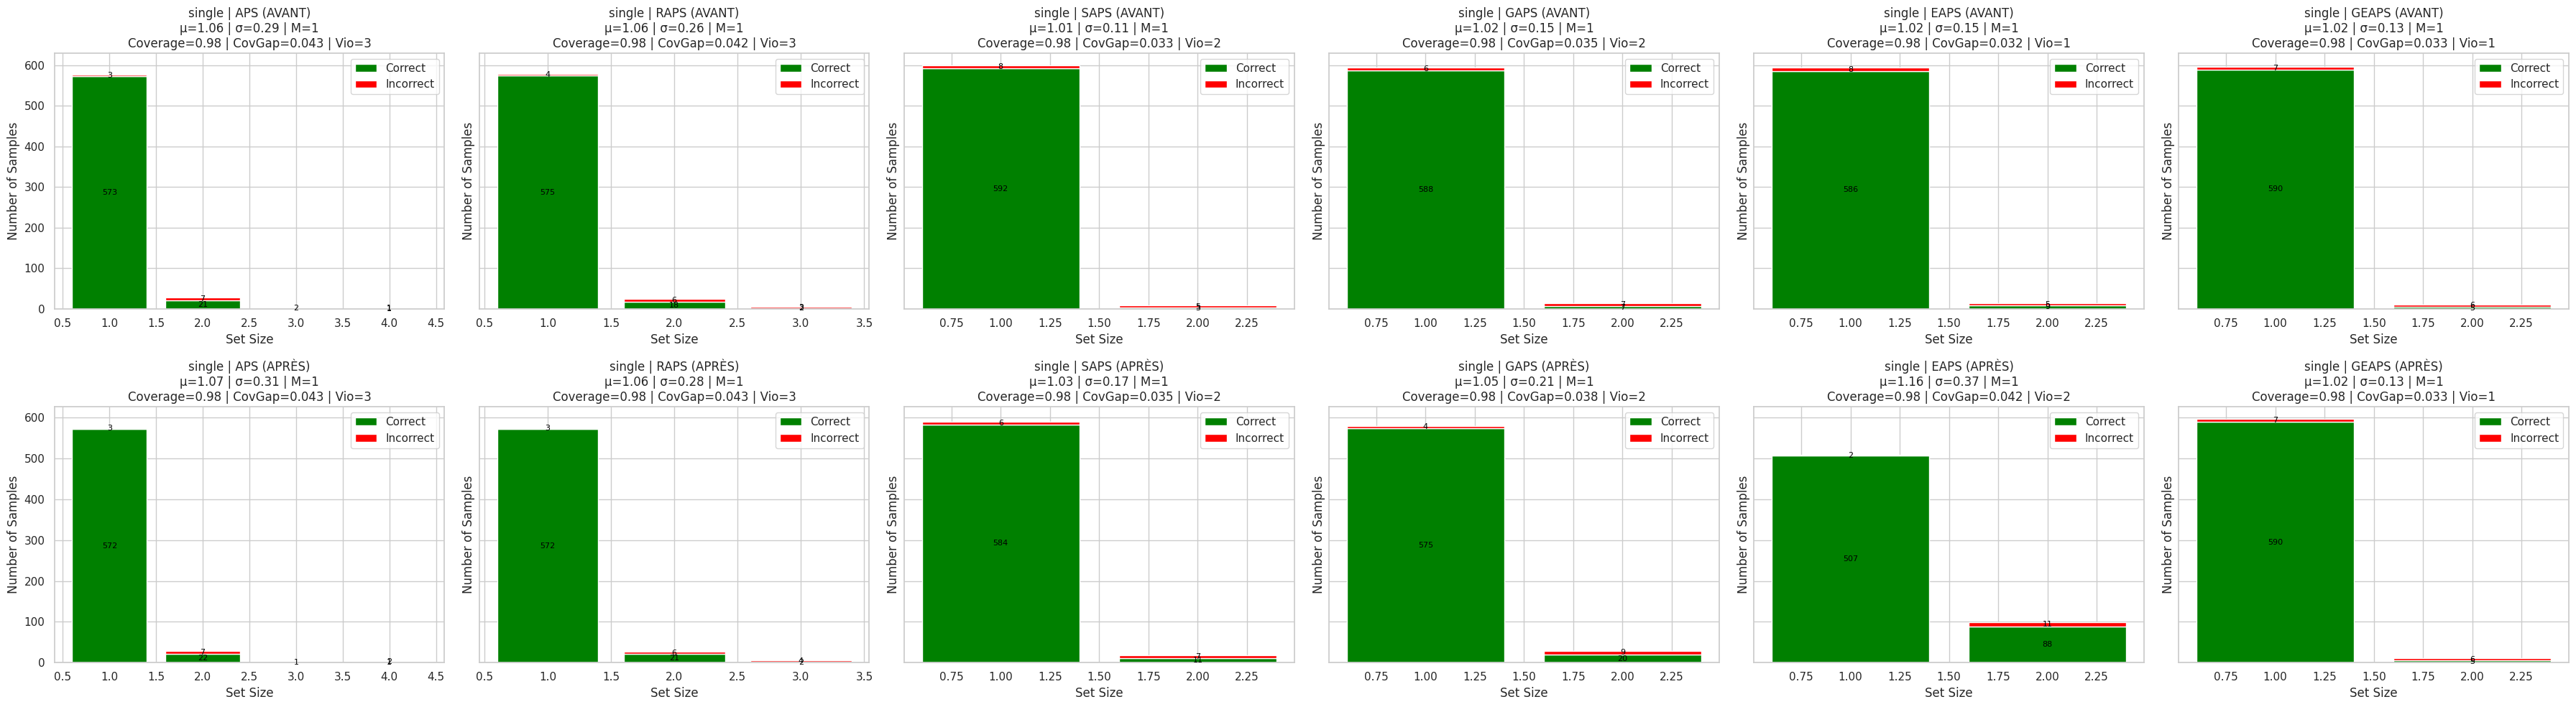

 <======================MCDropout approach======================>


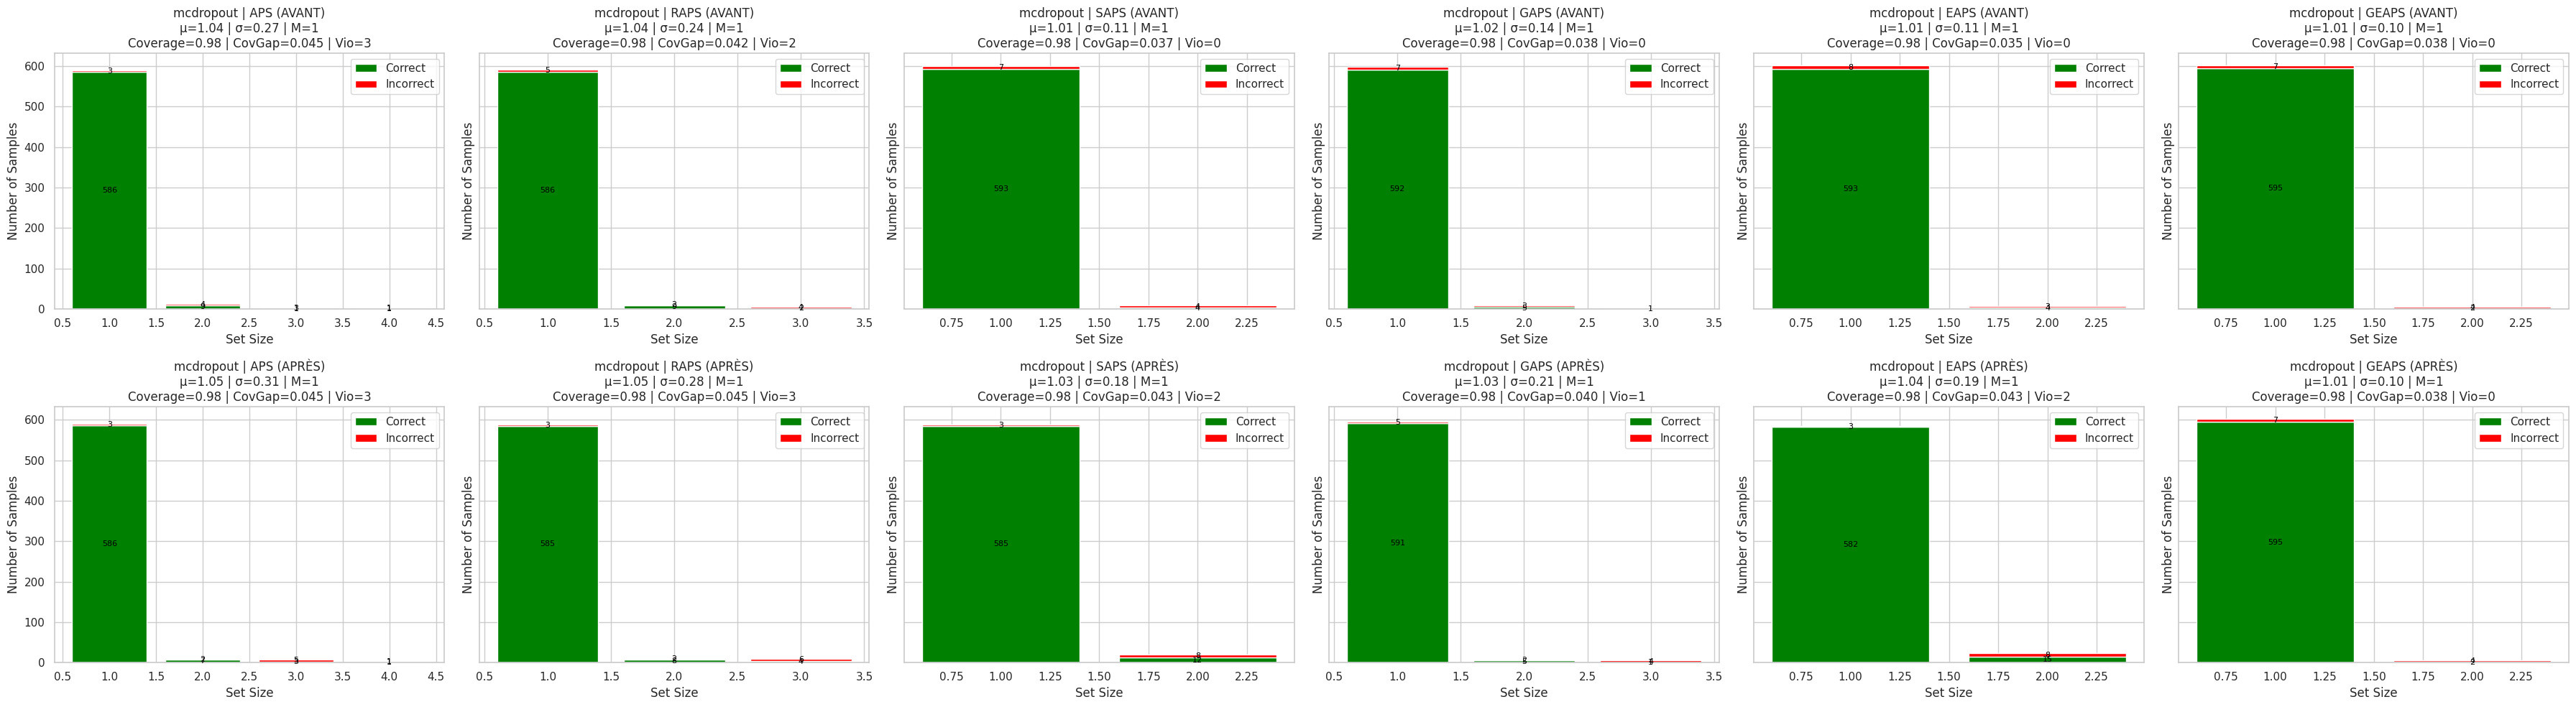

 <======================Deep Ensemble approach======================>


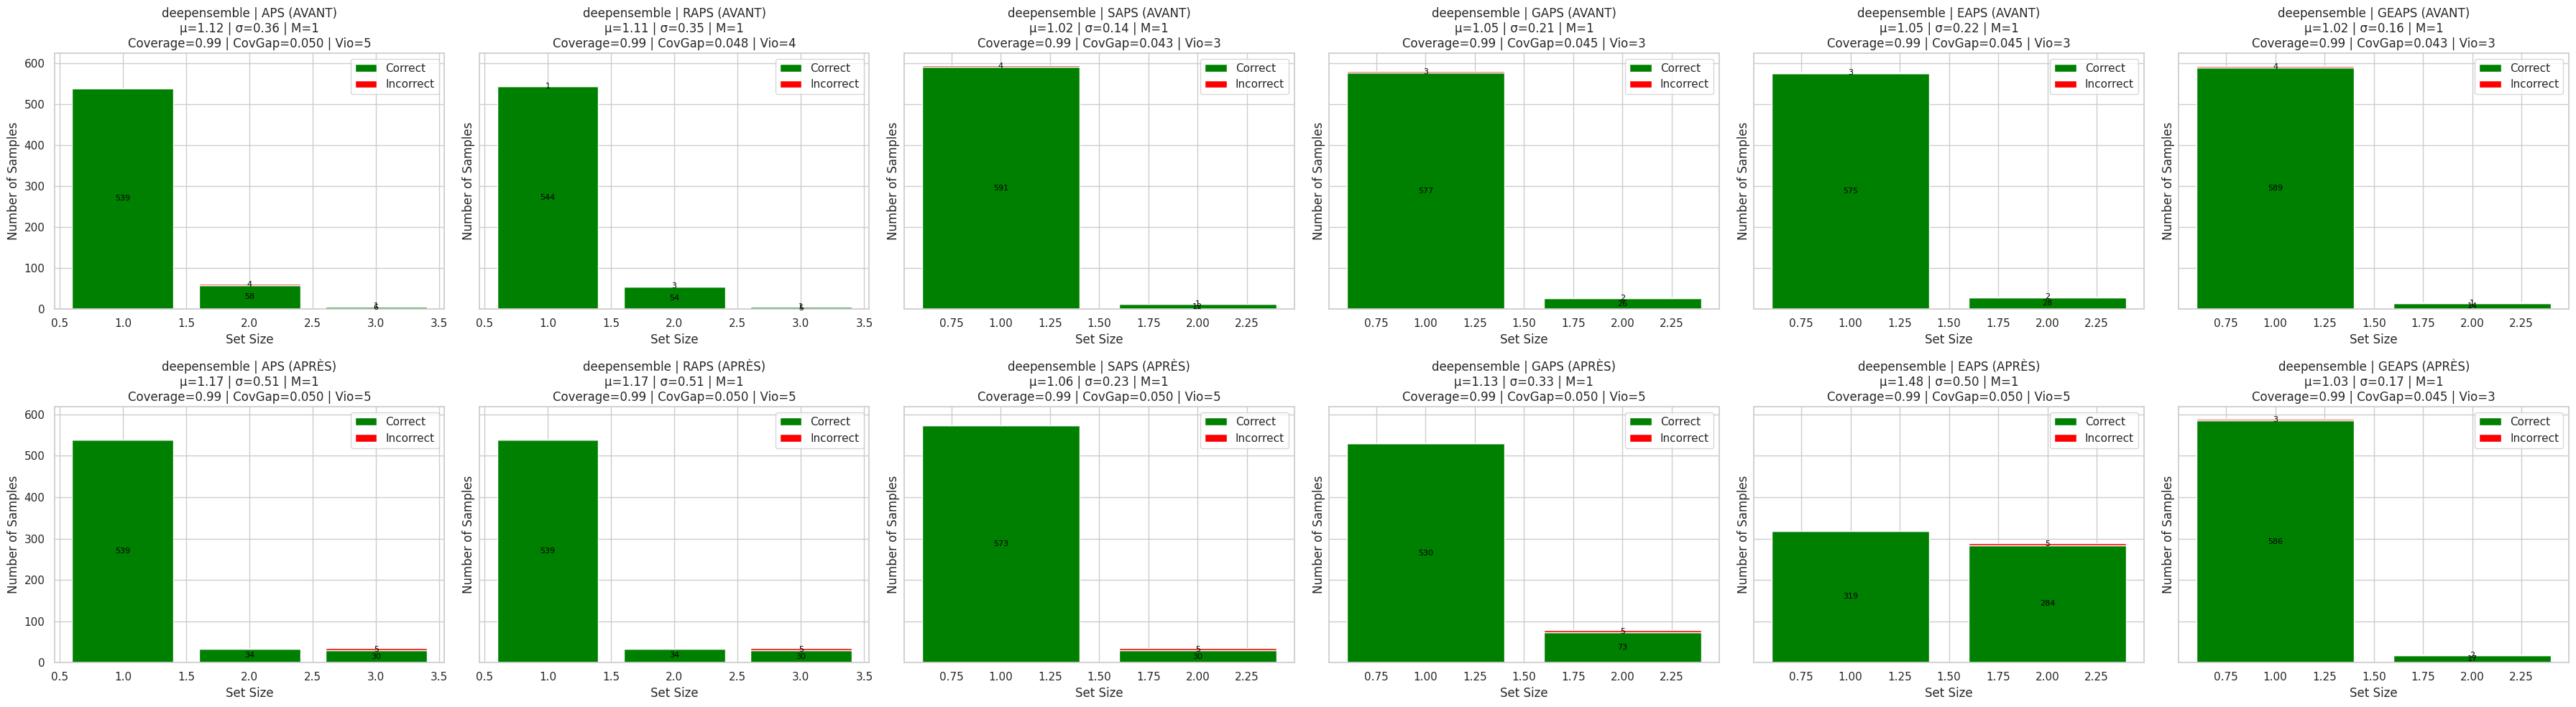

In [15]:
from src.utils.visualisation import plot_correct_incorrect_bars 

print(f" <======================Single approach======================>")
results_prediction_sn = plot_correct_incorrect_bars(
    predictors,
    test_probs=results_sn['y_probs'],
    y_test=results_sn['y_labels'],
    y_entropies=results_sn['entropy'],
    alpha=alpha,
    approach_name='single',
)

print(f" <======================MCDropout approach======================>")
results_prediction_mcd = plot_correct_incorrect_bars(
    predictors,
    test_probs=results_mcd['y_probs'],
    y_test=results_mcd['y_labels'],
    y_entropies=results_mcd['entropy'],
    alpha=alpha,
    approach_name='mcdropout',
)
print(f" <======================Deep Ensemble approach======================>") 
results_prediction__de = plot_correct_incorrect_bars(
    predictors,
    test_probs=results_de['y_probs'],
    y_test=results_de['y_trues'],
    y_entropies=results_de['entropy'],
    alpha=alpha,
    approach_name='deepensemble',
)

**4.2 Comparaison**

**4. Rejection Plot**

<======================single approach======================>
Cohen's d = -1.643
KS test statistic = 0.764, p-value = 3.14e-08


/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/utils/visualisation.py:329: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(ents, shade=True, alpha=0.5, color=color, label=label, ax=ax_right)
/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/utils/visualisation.py:329: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(ents, shade=True, alpha=0.5, color=color

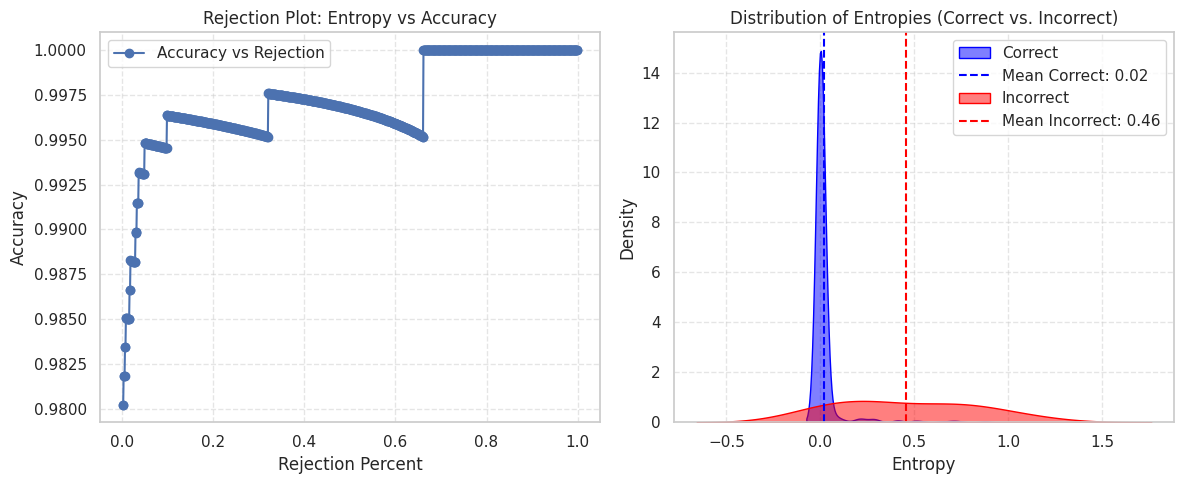

<======================mc_dropout approach======================>
Cohen's d = -1.603
KS test statistic = 0.805, p-value = 5.17e-08


/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/utils/visualisation.py:329: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(ents, shade=True, alpha=0.5, color=color, label=label, ax=ax_right)
/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/utils/visualisation.py:329: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(ents, shade=True, alpha=0.5, color=color

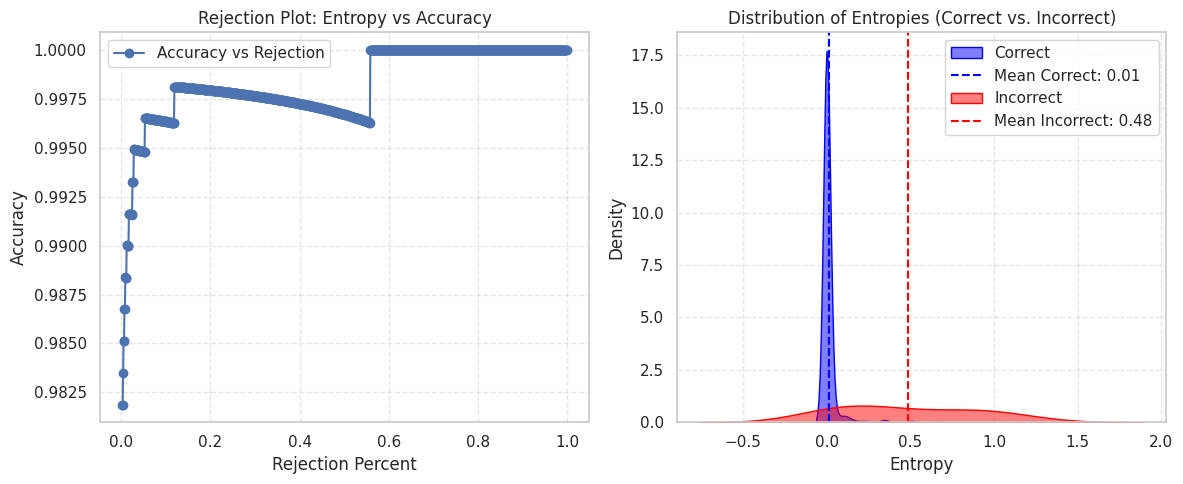

<======================deep_ensemble approach======================>
Cohen's d = -4.473
KS test statistic = 0.957, p-value = 4.99e-07


/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/conite/anaconda3/envs/GPU_ENV/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/utils/visualisation.py:329: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(ents, shade=True, alpha=0.5, color=color, label=label, ax=ax_right)
/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/src/utils/visualisation.py:329: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(ents, shade=True, alpha=0.5, color=color

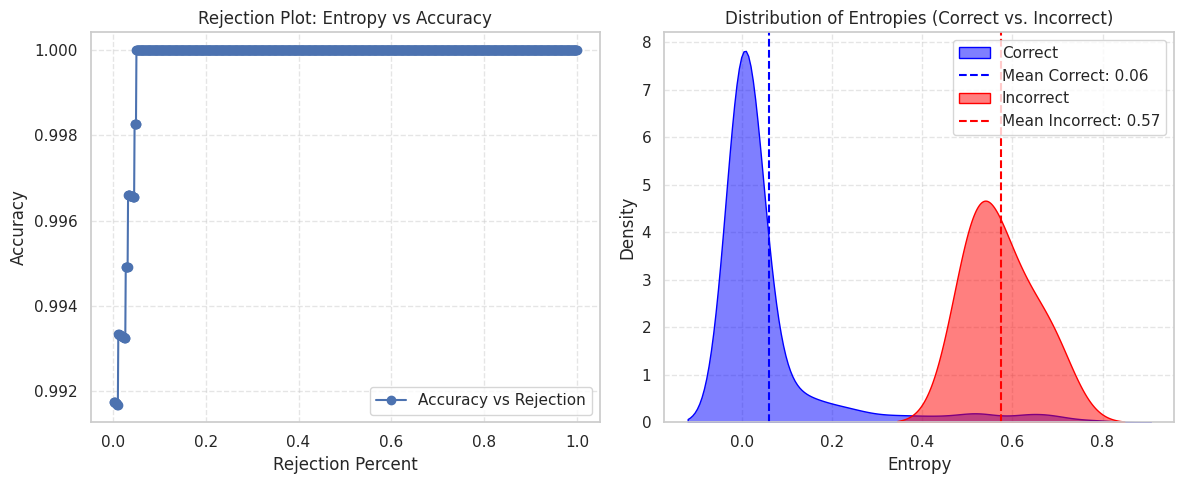

In [16]:
from src.utils.visualisation import rejection_plot_with_kde_distribution


approaches_names = ['single', 'mc_dropout', 'deep_ensemble']
for approach in approaches_names:
    print(f"<======================{approach} approach======================>")
    rejection_plot_with_kde_distribution(
        test_probs=results_sn['y_probs'] if approach == 'single' else results_mcd['y_probs'] if approach == 'mc_dropout' else results_de['y_probs'],
        y_test=results_sn['y_labels'] if approach == 'single' else results_mcd['y_labels'] if approach == 'mc_dropout' else results_de['y_trues'],
        entropies=results_sn['entropy'] if approach == 'single' else results_mcd['entropy'] if approach == 'mc_dropout' else results_de['entropy'],
        num_points=1000,
    )


In [17]:
# results_mcd

**Entropy VS Sets Size**

In [18]:
from src.utils.visualisation import analyze_entropy_vs_set_size_all_methods

 <======================Single approach======================>


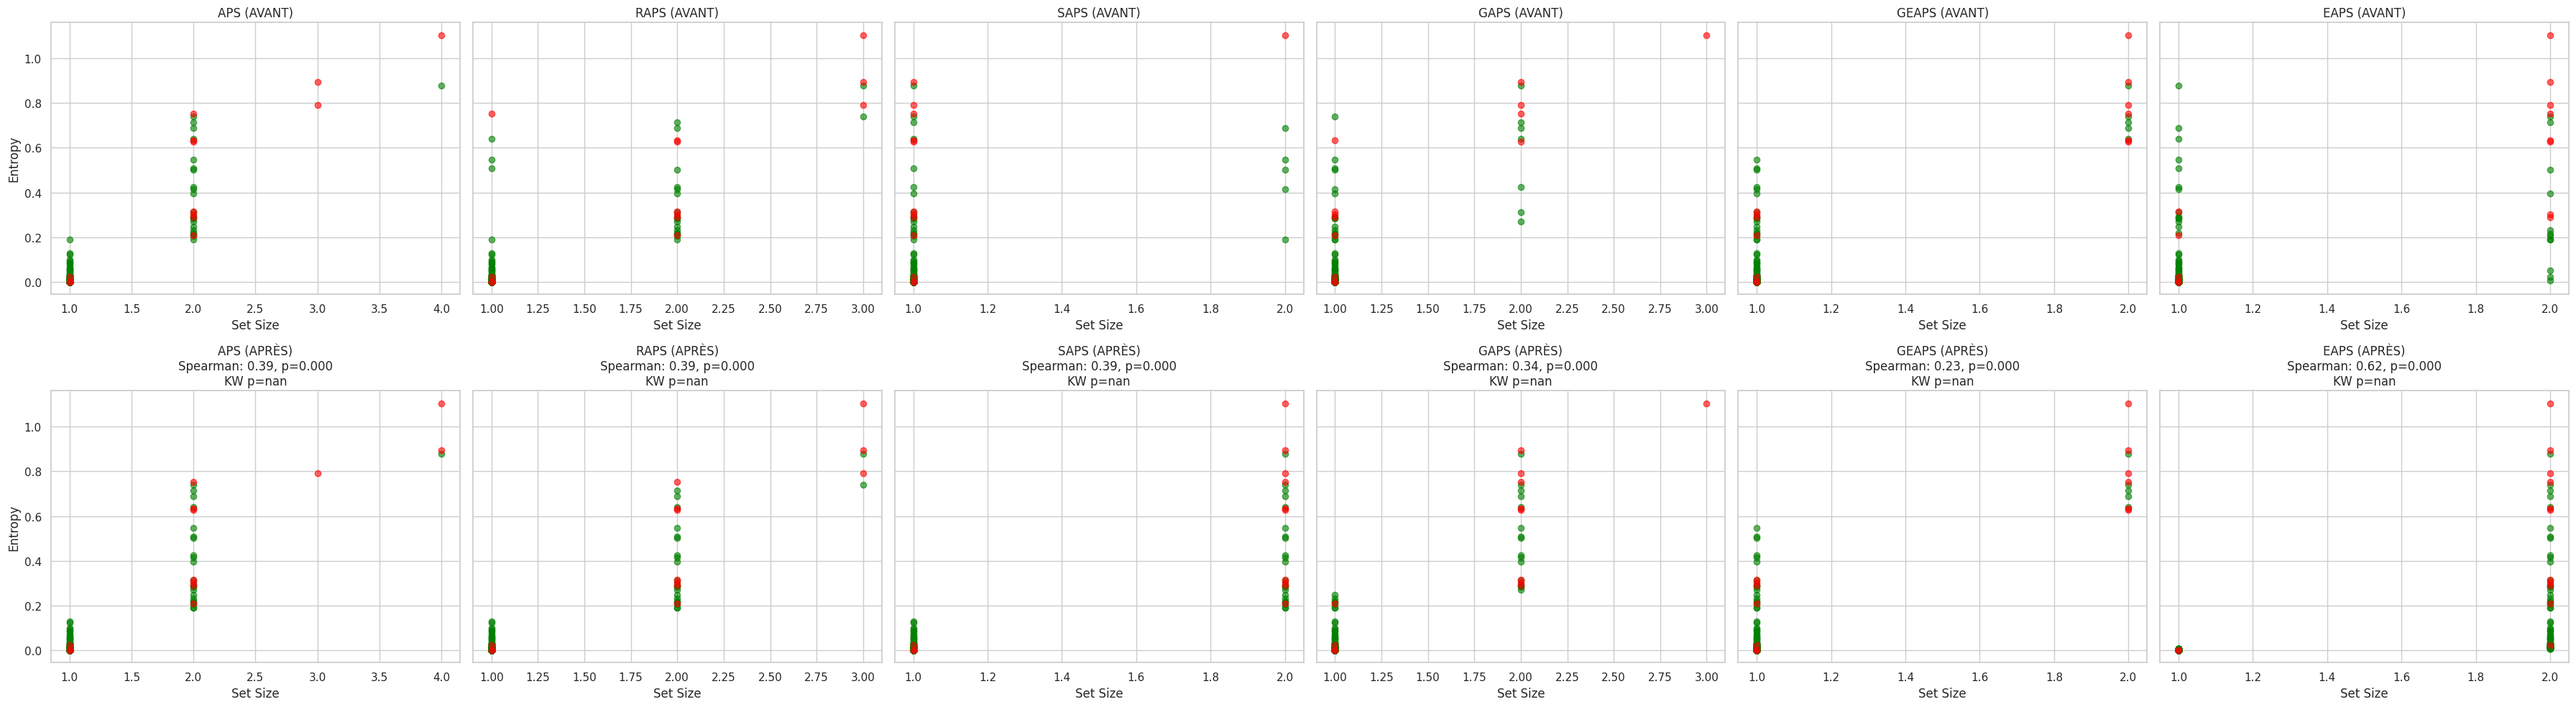

In [19]:
predictor_dict = {
    'APS': predictors['APS'],
    'RAPS': predictors['RAPS'],
    'SAPS': predictors['SAPS'],
    'GAPS': predictors['GAPS'],
    'GEAPS': predictors['GEAPS'],
    'EAPS': predictors['EAPS'],
}

print(f" <======================Single approach======================>")
results_scatter_sn_ =  analyze_entropy_vs_set_size_all_methods(
    predictor_dict,
    test_probs=results_sn['y_probs'],
    y_test=results_sn['y_labels'],
    entropies=results_sn['entropy']
)


 <======================MCDropout approach======================>


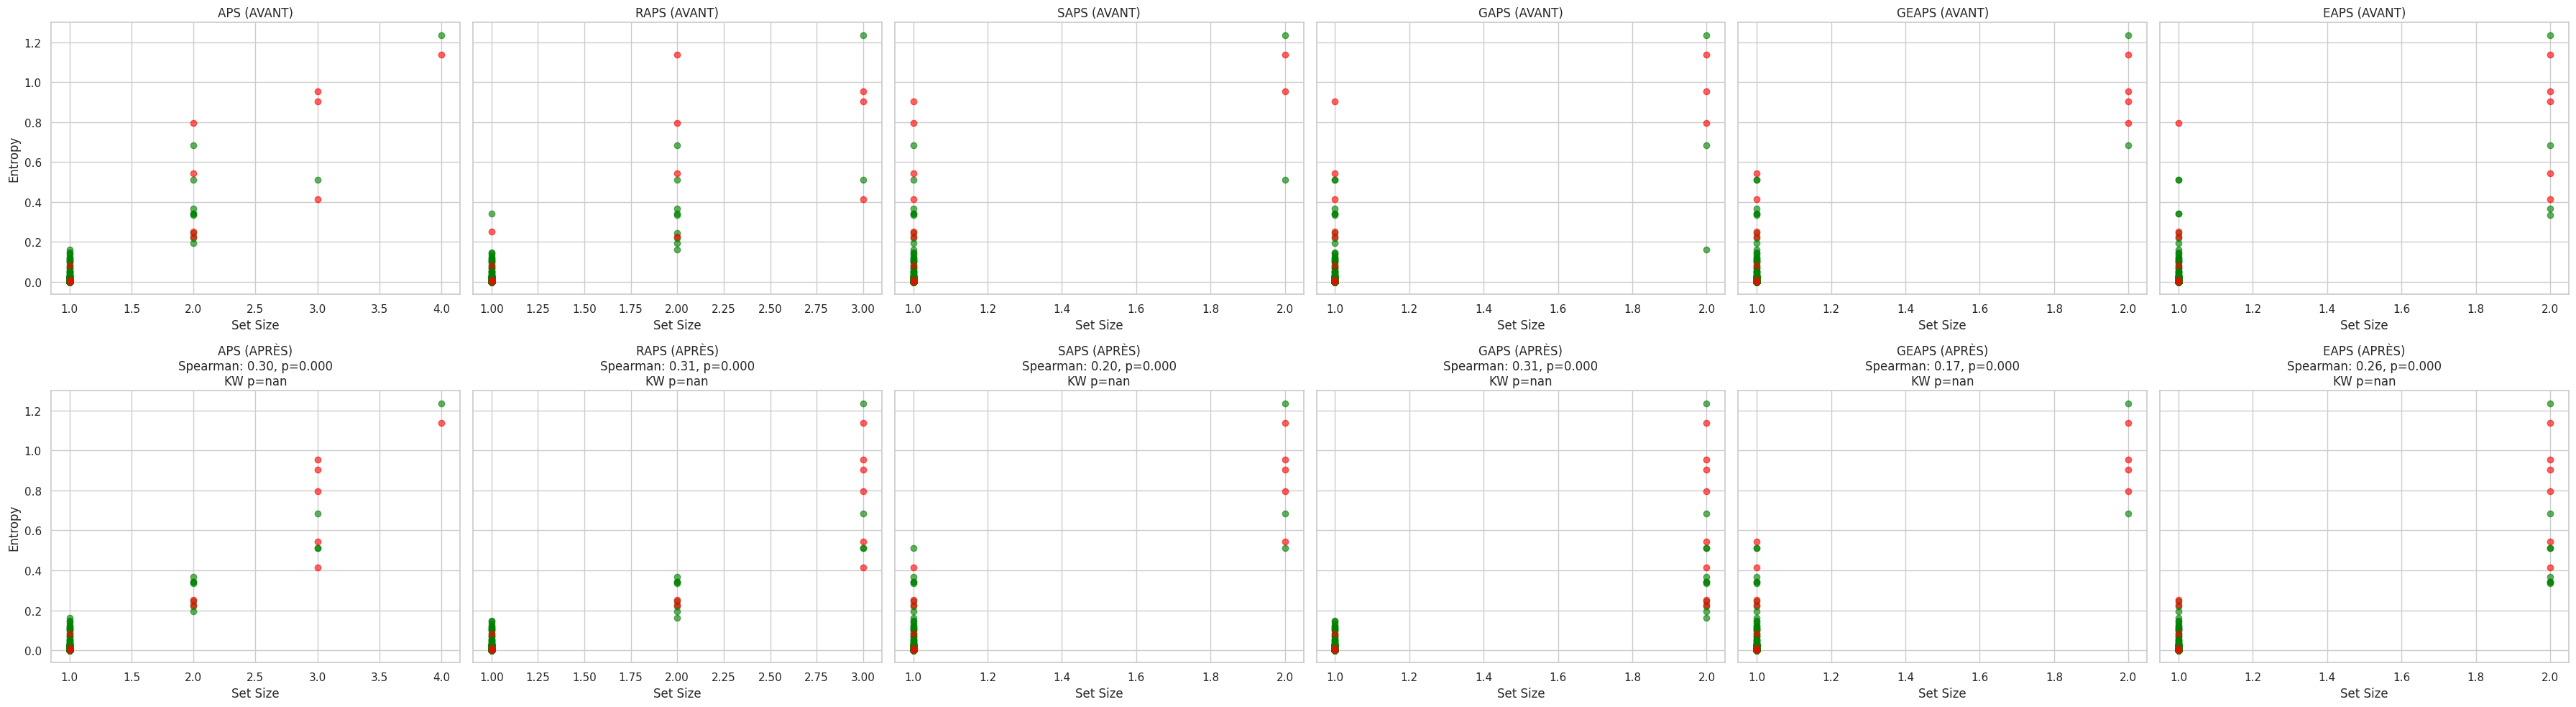

In [20]:
print(f" <======================MCDropout approach======================>")
results_scatter_mcd_ =  analyze_entropy_vs_set_size_all_methods(
    predictor_dict,
    test_probs=results_mcd['y_probs'],
    y_test=results_mcd['y_labels'],
    entropies=results_mcd['entropy']
)

 <======================Deep Ensemble approach======================>


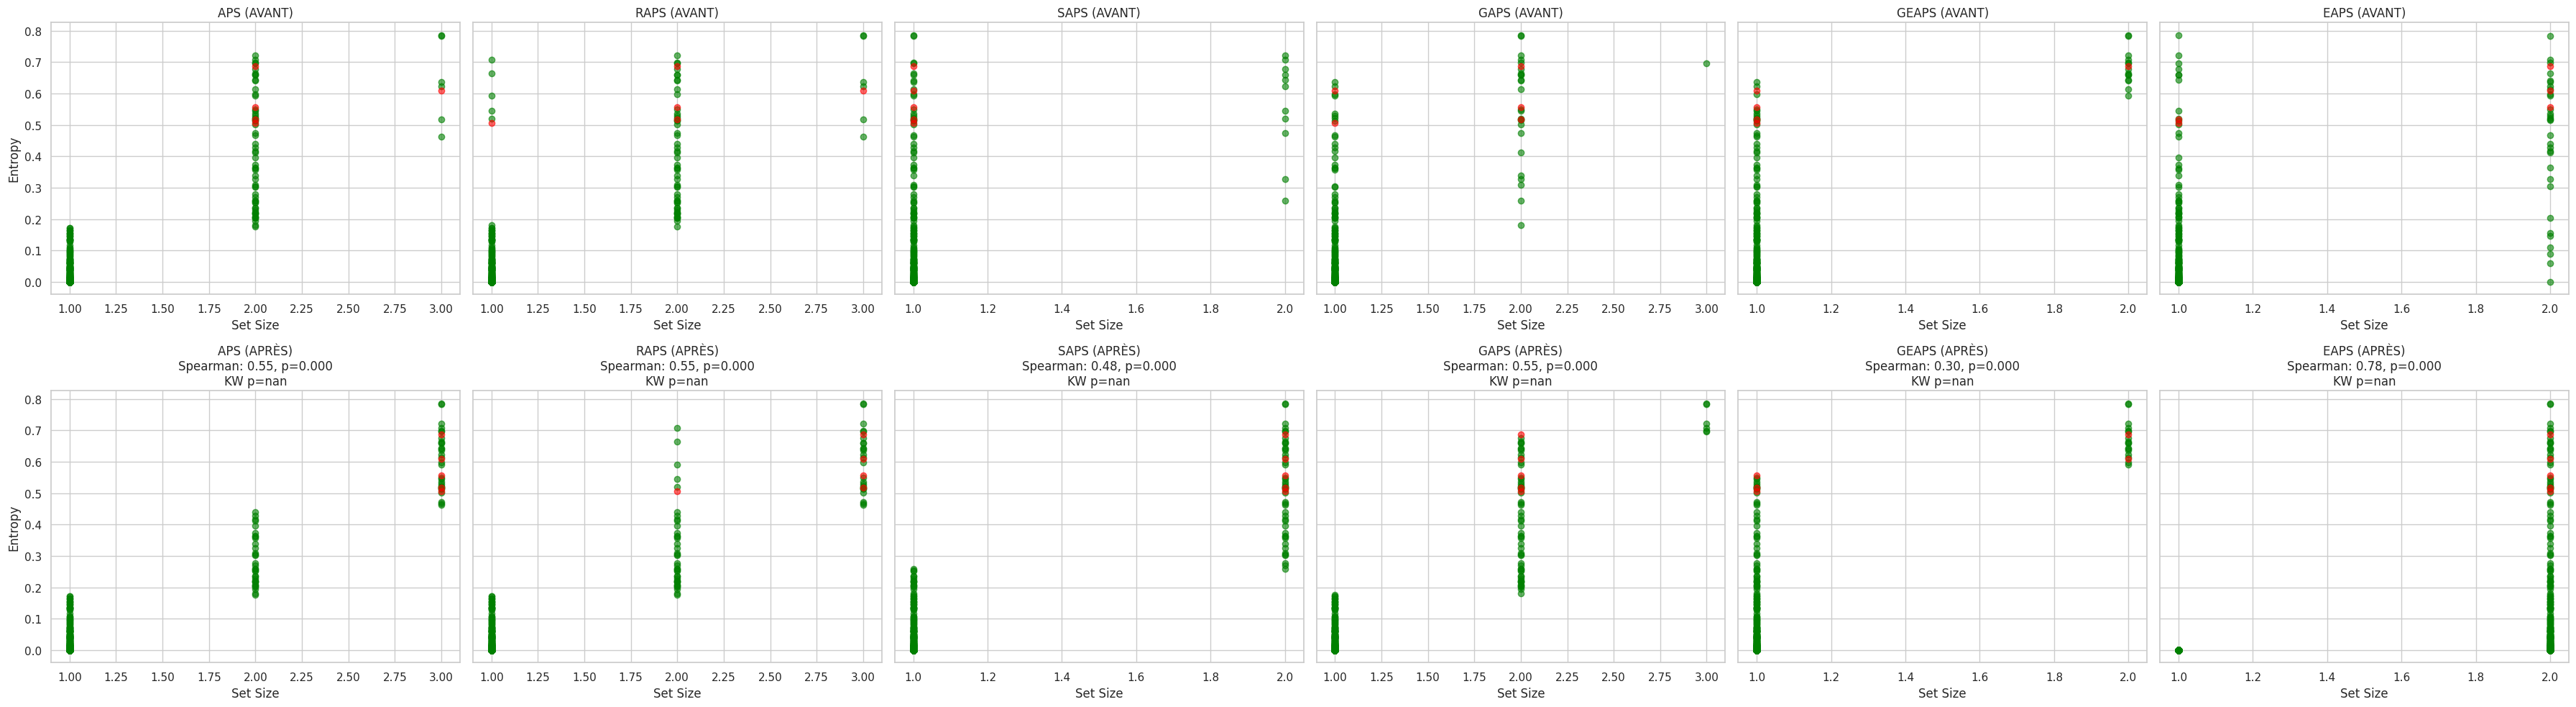

In [21]:
print(f" <======================Deep Ensemble approach======================>")
results_scatter_de_ =  analyze_entropy_vs_set_size_all_methods(
    predictor_dict,
    test_probs=results_de['y_probs'],
    y_test=results_de['y_trues'],
    entropies=results_de['entropy']
)

**06 ODD Detection**

In [22]:
from src.ood.ood_detection import create_ood_dataset

ood_dataset_dir = "../data/ood_dataset_sipakmed"
image_urls = [
    "https://cdn.pixabay.com/photo/2024/02/24/17/37/lemons-8594421_1280.jpg",
    "https://cdn.pixabay.com/photo/2022/04/05/17/06/butterfly-7114037_640.jpg",
    "https://cdn.pixabay.com/photo/2025/03/21/21/22/roche-9485693_640.jpg",
    "https://cdn.pixabay.com/photo/2021/12/04/20/59/animal-6845972_1280.jpg",
    "https://cdn.pixabay.com/photo/2025/02/25/04/25/desert-9429492_640.jpg"
]

create_ood_dataset(image_urls, ood_dataset_dir)

Downloaded and saved ood_0.jpg
Downloaded and saved ood_1.jpg
Downloaded and saved ood_2.jpg
Downloaded and saved ood_3.jpg
Downloaded and saved ood_4.jpg


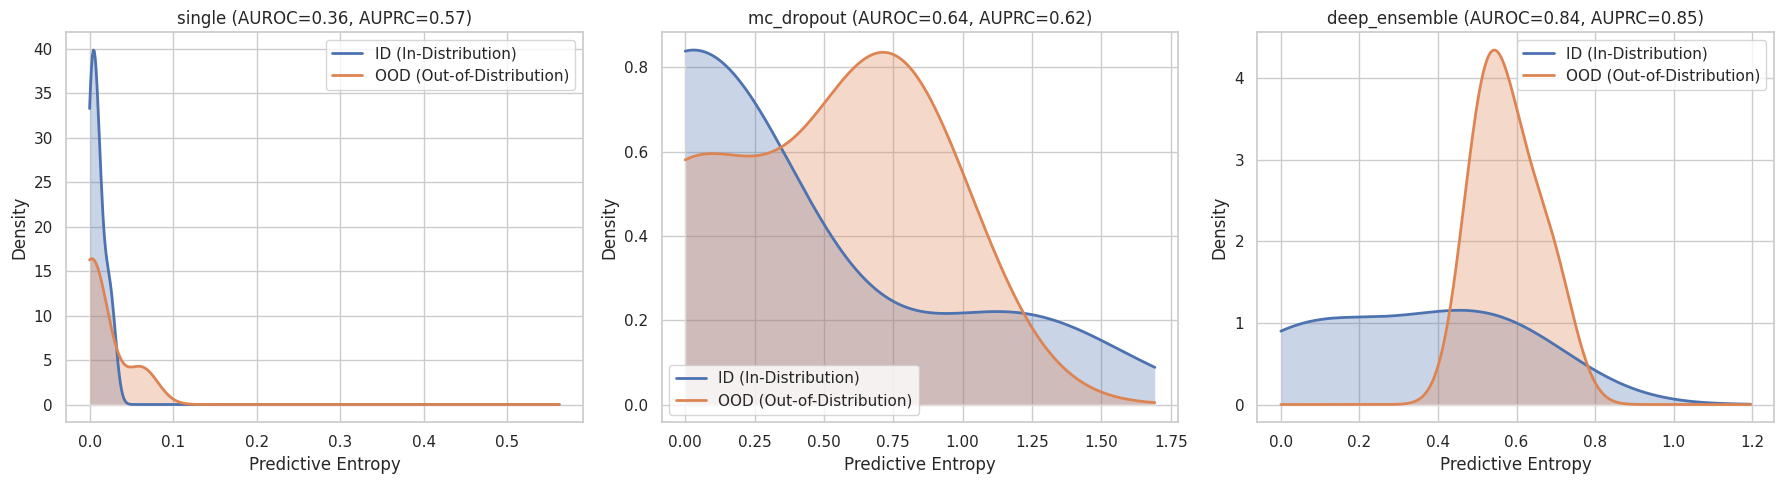

In [23]:
from src.ood.ood_detection  import evaluate_ood_entropy_all

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
id_dir = "/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/data/in_data_sipakmed"
ood_dir = ood_dataset_dir
evaluate_ood_entropy_all(
    models_dict={
        "single": single_net.model,
        "mc_dropout": mcdropout.model,
        "deep_ensemble": deepensemble.models,
    },
    id_dir=id_dir,
    ood_dir=ood_dir,
    device=DEVICE,
    num_passes=5
)


**7.0 Explanability**

100%|██████████| 5/5 [00:00<00:00, 34.16it/s]


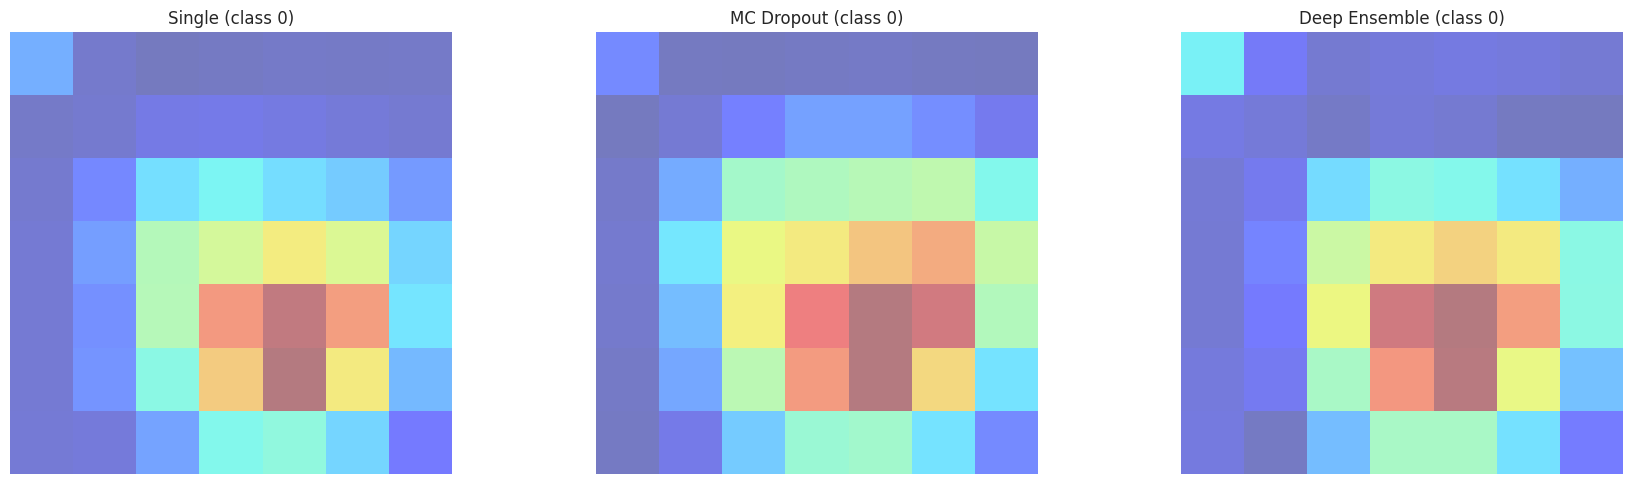

In [24]:
from src.explainability.methods import get_image_and_cam, show_all_gradcams
from src.ood.ood_detection import load_image_tensor

image_tensor = load_image_tensor("/home/conite/Documents/STAGE/HybridUncertaintyDLFramework/data/in_data_sipakmed/dyskeratotic.jpg")
cams = {
    "Single": get_image_and_cam(single_net.model, image_tensor, DEVICE, approach="single"),
    "MC Dropout": get_image_and_cam(mcdropout.model, image_tensor, DEVICE, approach="mc_dropout"),
    "Deep Ensemble": get_image_and_cam(deepensemble.models, image_tensor, DEVICE, approach="deep_ensemble")
}

show_all_gradcams(image_tensor, cams)